In [3]:
%load_ext autoreload
%autoreload 2

# add Code folder, if the package is not installed.
import sys
sys.path.append('../src')


In [4]:

# import main class and plotting function
from qdarts.experiment import Experiment
from qdarts.plotting import plot_polytopes


# import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [5]:
def get_truth(C_DD, C_DG):
    N = C_DD.shape[0]
    C_DD_maxwell = np.zeros((N,N))
    C_DG_maxwell = np.zeros((N,N))
    for k in range(N):
        for l in range(N):
            if k==l:
                C_DD_maxwell[k,l] = np.sum(C_DD[k,:]+ C_DG[k,:]) 
            else:
                C_DD_maxwell[k,l] = -C_DD[k,l]
            
            C_DG_maxwell[k,l] = C_DG[k,l]
    C_DDinv = np.linalg.inv(C_DD_maxwell)  # C_DDmaxwel are the saem
    e_aF = 1.6*1e-19/1e-18  #e/aF

    dVx = C_DDinv[0,0]/(C_DDinv @ C_DG)[0,0]
    dVy = C_DDinv[1,1]/(C_DDinv @ C_DG)[1,1]

    dVx  = dVx* e_aF 
    dVy  = dVy* e_aF 

    alpha = C_DDinv @ C_DG
    theta1 = np.arctan(alpha[0,1]/alpha[0,0])
    theta2 = np.arctan(alpha[1,0]/alpha[1,1])
    return dVx, dVy, theta1, theta2

In [6]:
def get_csd(C_DD, C_DG, tunnel_couplings, noise):
        capacitance_config = {
        "C_DD" : C_DD,  #dot-dot capacitance matrix
        "C_Dg" : C_DG,  #dot-gate capacitance matrix
        "ks" : None,       #distortion of Coulomb peaks. NOTE: If None -> constant size of Coublomb peak 
        }

        tunneling_config = {
                "tunnel_couplings": tunnel_couplings, #tunnel coupling matrix
                "temperature": 0.1,                   #temperature in Kelvin
                "energy_range_factor": 5,  #energy scale for the Hamiltonian generation. NOTE: Smaller -> faster but less accurate computation 
        }
        sensor_config = {
                "sensor_dot_indices": [2],  #Indices of the sensor dots
                "sensor_detunings": [-0.0001],  #Detuning of the sensor dots
                "noise_amplitude": {"fast_noise": noise, "slow_noise": noise}, #Noise amplitude for the sensor dots in eV
                "peak_width_multiplier": 60,  #Width of the sensor peaks in the units of thermal broadening m *kB*T/0.61.
        }

        # Create the experiment object
        exp = Experiment(capacitance_config, tunneling_config, sensor_config)

        dVx, dVy, theta1, theta2 = get_truth(C_DD, C_DG)

        Nd = 2

        xexp, yexp, csd, polytopesexp, sensor_signalexp, _ = exp.generate_CSD(
                                                plane_axes = np.array([[1,0,0],[0,1,0]
                                                            
                                                            ]), # vectors spanning the cut in voltage space
                                                #target 
                                                target_state = [1,0,5],
                                                target_transition = [-1,1,0],
                                                #transition from target state, here transition 
                                                #to [2,3,2,3,5,5]
                                                x_voltages=np.linspace(-dVx, Nd*dVx, 150), #voltage range for x-axis
               
                                                y_voltages=np.linspace(-dVy, Nd*dVy
                                                , 150), #voltage range for y-axis
                                                compute_polytopes = True,
                                                use_sensor_signal=True
                                                )
        
        return xexp, yexp, sensor_signalexp, dVx, dVy, theta1, theta2
        


EXPERIMENT INITIALIZED
-----------------------

                Capacitance model deployed with the following parameters:
                Dot-dot capacitances: 
                [[  0.           2.1659559    0.43319118]
 [  2.1659559    0.           0.29127335]
 [  0.43319118   0.29127335 100.        ]]
                Dot-gate capacitances: 
                [[8.35569484 0.53402954 0.        ]
 [0.24429818 6.26175926 0.        ]
 [0.         0.         8.35815441]]
                Size of Coulomb peaks V[n] is constant
                

            Sensor model deployed with the following parameters:   
            Sensor dot indices: [2]
            Sensor detunings: [-0.1] meV
            Coulomb peak width: 1.64 meV
            Slow noise amplitude: 3.1623 ueV
            Fast noise amplitude: 3.1623 ueV
            Signal noise scale: 0.0
            

            Tunneling model deployed with the following parameters:
            Tunneling matrix:
            [[0. 0. 0.]
 [0. 0. 0.

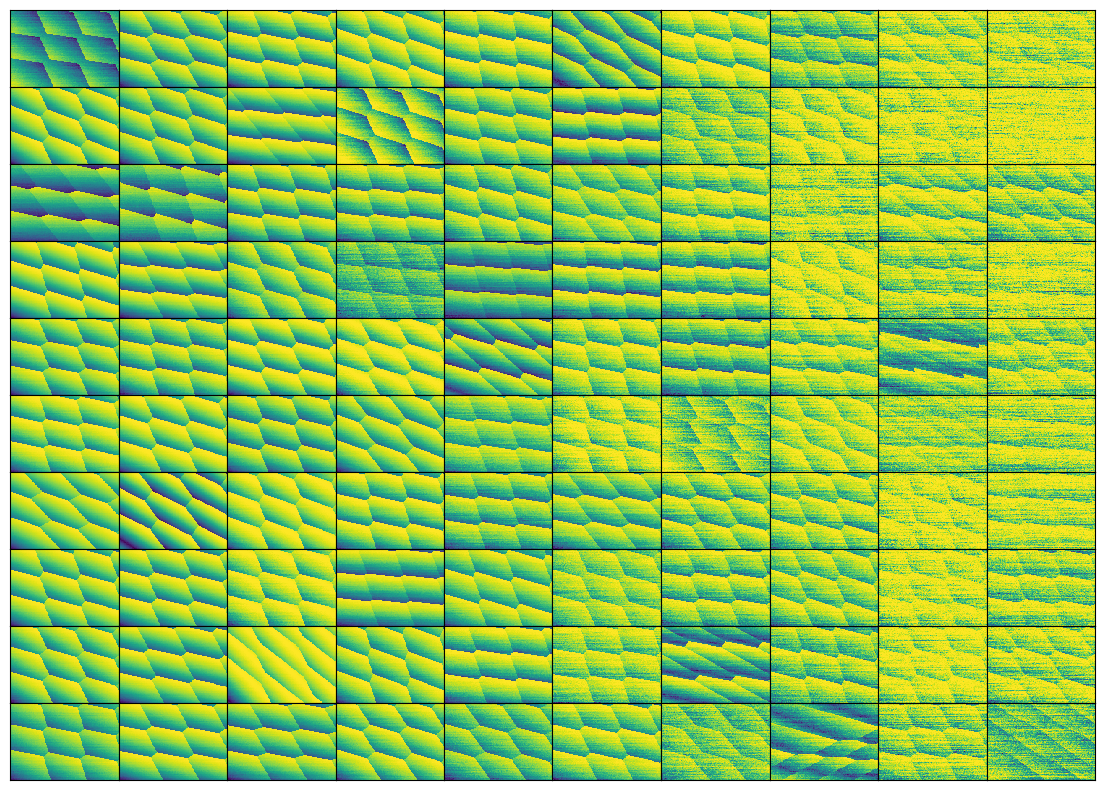

In [7]:
# Define the system

#All capacitances are given in aF
N = 3  #number of dots   

noise_levels = np.logspace(-5.5,-4,10)
Nsamples = 25
fig, ax = plt.subplots(10,len(noise_levels), figsize = (14,10))
plt.subplots_adjust(wspace = 0.0, hspace = 0.0)

for x, noise in enumerate(noise_levels):
    n = -1 
    while n < Nsamples-1:
        C_DD = np.zeros((N,N))
        C_DG = np.zeros((N,N))
        avg_m, sig_m = 2, 1
        avg_s, sig_s = 4, 2
        avg_g, sig_g = 5,2
        avg_gcross, sig_gcross = 0.5, 0.2

        C_m = np.random.normal(avg_m, sig_m)
        C_s = np.random.normal(avg_m, sig_m)
        C_DD[0,1] = C_m
        C_DD[1,2] = C_s
        C_DD[0,2] = C_m*0.2

        C_DD = C_DD + C_DD.T #symmetrize
        C_DD[-1,-1] = 100

        C_DG = np.diag(np.random.normal(avg_g,sig_g, size = N))
        C_DG[0,1], C_DG[1,0] = np.random.normal(avg_gcross, sig_gcross, size = 2)

        # NOTE: we use the convention that tc is the energy gap at avoided crossing H = tc/2 sx
        tunnel_couplings = np.zeros((N,N))
        tunnel_couplings[0,1] = 1e-9999
        try: 
            xexp, yexp, sensor_signalexp, dVx, dVy, theta1, theta2 = get_csd(C_DD, C_DG, tunnel_couplings, noise_levels[x])
            n += 1
        except:
            continue
        if n<10:
            ax[n,x].pcolormesh(sensor_signalexp[:,:,0])
            ax[n,x].set_xticks([])
            ax[n,x].set_yticks([])
        np.save(f'data/{x}_{n}_xexp.npy', xexp)
        np.save(f'data/{x}_{n}_yexp.npy', yexp)
        np.save(f'data/{x}_{n}_csd.npy', sensor_signalexp[:,:,0])
        np.save(f'data/{x}_{n}_truth.npy', np.array([dVx, dVy, theta1, theta2]))
plt.savefig('data/fig1.png')